Introduction

Music genre classification is a common machine learning task that focuses on predicting the genre of a song using measurable audio characteristics. In this project, I use the GTZAN dataset, a well-known music dataset containing audio clips from 10 genres: blues, classical, country, disco, hiphop, jazz, metal, pop, reggae, and rock. Since raw audio files are difficult to use directly in standard machine learning models, the audio was transformed into a structured dataset called features_3_sec.csv, where each row represents a short audio segment and each column contains extracted sound features such as tempo, chroma, spectral centroid, bandwidth, root mean square energy, and MFCC coefficients. The target variable is the genre label associated with each segment.
The main goal of this project is to determine whether these extracted audio features can be used to accurately classify music into its correct genre. More specifically, I want to explore which features seem most helpful for distinguishing genres and which machine learning models perform best on this classification task. Because genre is a multiclass outcome, this project also examines which genres are easier to predict and which are more likely to be confused with one another.
I chose this topic because music is something I connect with personally, especially piano-based music. I have always been drawn to the piano and the way it can shape the mood, style, and identity of a piece. That personal interest made music genre classification feel like a meaningful project, since it combines data science with something I genuinely enjoy. Working on this topic also gave me the chance to better understand how musical qualities can be translated into numerical features and analyzed with machine learning methods.
This project begins with exploratory data analysis to better understand the distribution of genres and the behavior of important audio features. After that, the data is split into training and testing sets, and cross-validation is used to evaluate model performance in a reliable way. Multiple classification models are then fit and compared in order to identify the approach that produces the strongest predictions. Overall, this project aims to show how machine learning can be applied to audio data and how feature-based methods can help distinguish different styles of music.


Exploratory Data Analysis

To better understand the structure of the dataset before fitting models, I performed exploratory data analysis on the extracted audio features in features_3_sec.csv. This dataset contains 9,990 observations and 60 columns, with each row representing a 3-second audio segment and the target variable given by the genre label. The purpose of this section is to examine the distribution of the outcome variable, explore relationships between genre and selected predictors, and identify patterns among the audio features that may be important for classification.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("../data/features_3_sec.csv")
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [ ]:
print(df.shape)

(9990, 60)


/var/folders/yg/7nk1y4d97z17ldm0l72nl2640000gn/T/ipykernel_6476/1362158000.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='muted')


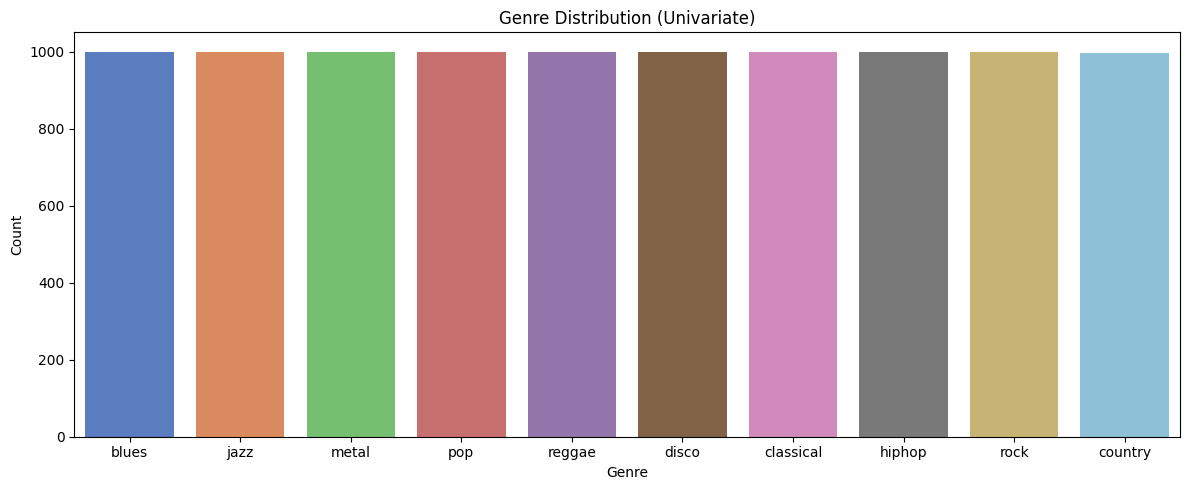

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index, palette='muted')
plt.title('Genre Distribution (Univariate)')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The count plot of genre labels shows that the dataset is evenly balanced across all 10 genres, with about the same number of observations in each class. This is helpful for classification because it reduces the risk that a model will become biased toward predicting one genre more often simply because it appears more frequently in the data. Since the classes are balanced, evaluation metrics such as accuracy will be easier to interpret.

/var/folders/yg/7nk1y4d97z17ldm0l72nl2640000gn/T/ipykernel_6476/278303917.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='tempo', palette='muted')


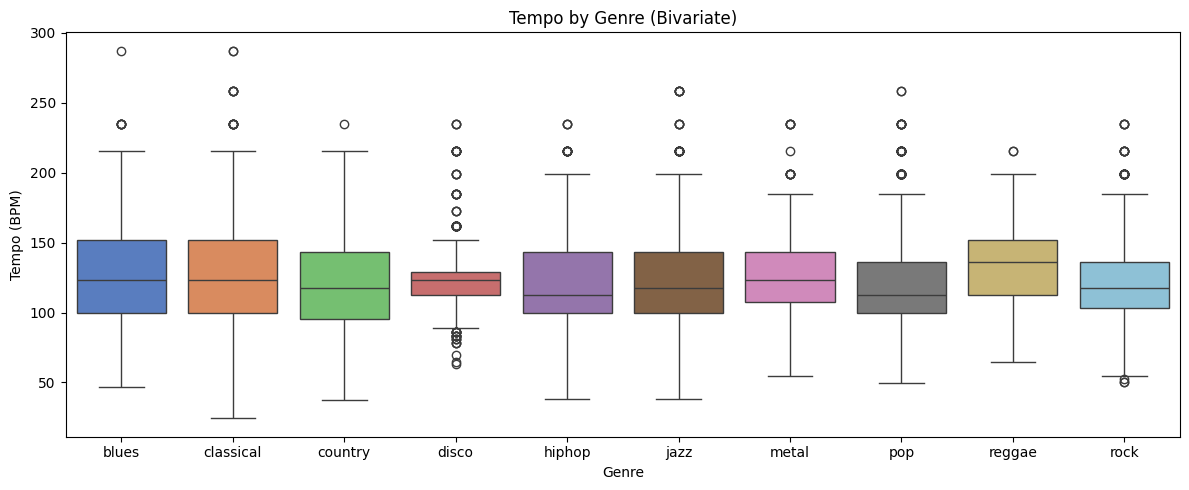

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='label', y='tempo', palette='muted')
plt.title('Tempo by Genre (Bivariate)')
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.tight_layout()
plt.show()

The boxplot of tempo by genre shows that there is variation in tempo distributions across genres, although the ranges overlap substantially. Some genres, such as reggae, appear to have slightly higher median tempo values, while others such as hiphop tend to have somewhat lower central values. However, because there is still a large amount of overlap, tempo alone is unlikely to be sufficient for separating genres perfectly. This suggests that tempo may be useful as one predictor among many rather than as a dominant feature by itself.

/var/folders/yg/7nk1y4d97z17ldm0l72nl2640000gn/T/ipykernel_6476/1264579040.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='spectral_centroid_mean', palette='muted')


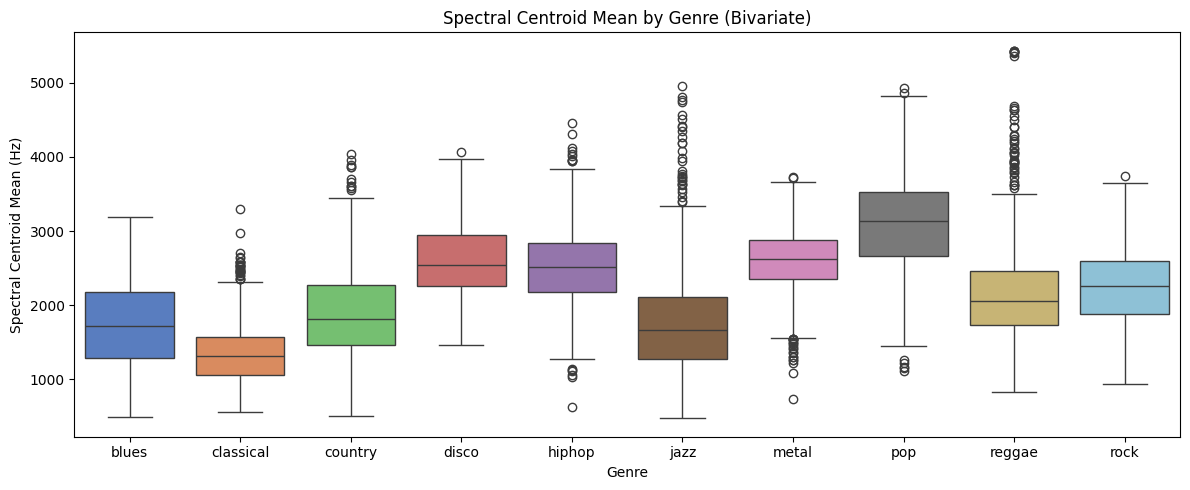

In [ ]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='label', y='spectral_centroid_mean', palette='muted')
plt.title('Spectral Centroid Mean by Genre (Bivariate)')
plt.xlabel('Genre')
plt.ylabel('Spectral Centroid Mean (Hz)')
plt.tight_layout()
plt.show()

The spectral centroid boxplot shows clearer separation across genres than tempo. Genres such as pop, metal, disco, and hiphop tend to have higher spectral centroid values, while classical and jazz appear to have lower median values. Since spectral centroid is often interpreted as a measure of the “brightness” of a sound, this result suggests that timbral differences may help distinguish genres. At the same time, the presence of outliers and overlapping ranges indicates that no single feature is likely to fully classify all genres on its own.

In [ ]:
feature_variance = df.groupby('label').mean(numeric_only=True).T.var(axis=1).sort_values(ascending=False)
top_features = feature_variance.head(8).index.tolist()
print("Top 8 most discriminative features:", top_features)

Top 8 most discriminative features: ['rolloff_var', 'spectral_centroid_var', 'spectral_bandwidth_var', 'rolloff_mean', 'mfcc1_var', 'spectral_centroid_mean', 'spectral_bandwidth_mean', 'mfcc2_var']


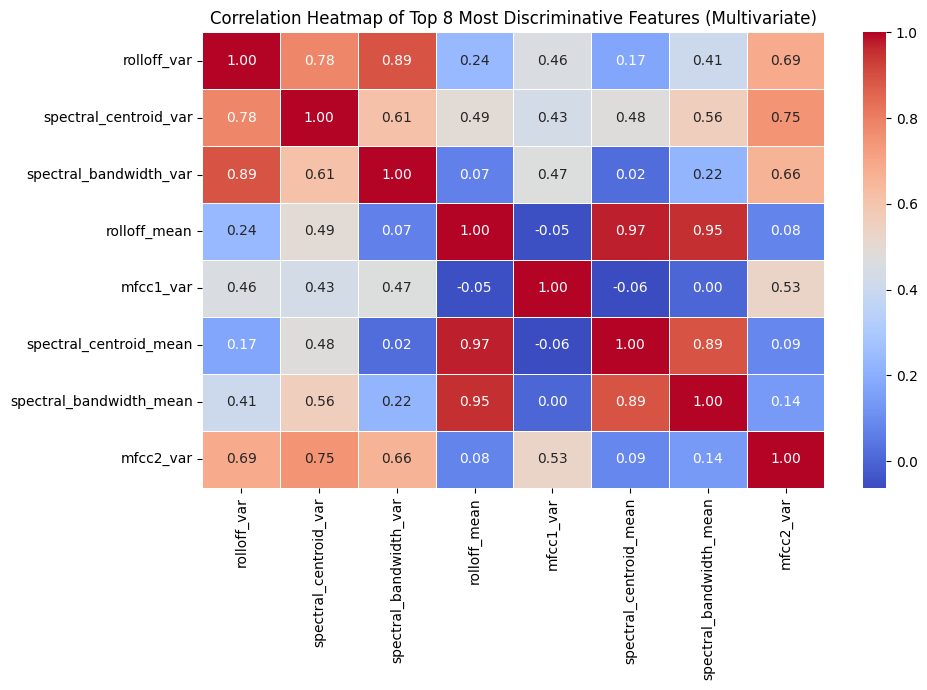

In [ ]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Top 8 Most Discriminative Features (Multivariate)')
plt.tight_layout()
plt.show()

The correlation heatmap of the most discriminative features shows that several spectral variables are strongly correlated with one another. For example, rolloff_mean, spectral_centroid_mean, and spectral_bandwidth_mean have high positive correlations. This could suggests that these features may be capturing similar information about the frequency content of the music. From a modeling perspective, this could matter for linear models, where multicollinearity may affect interpretation, while tree-based models may be less sensitive to this issue.

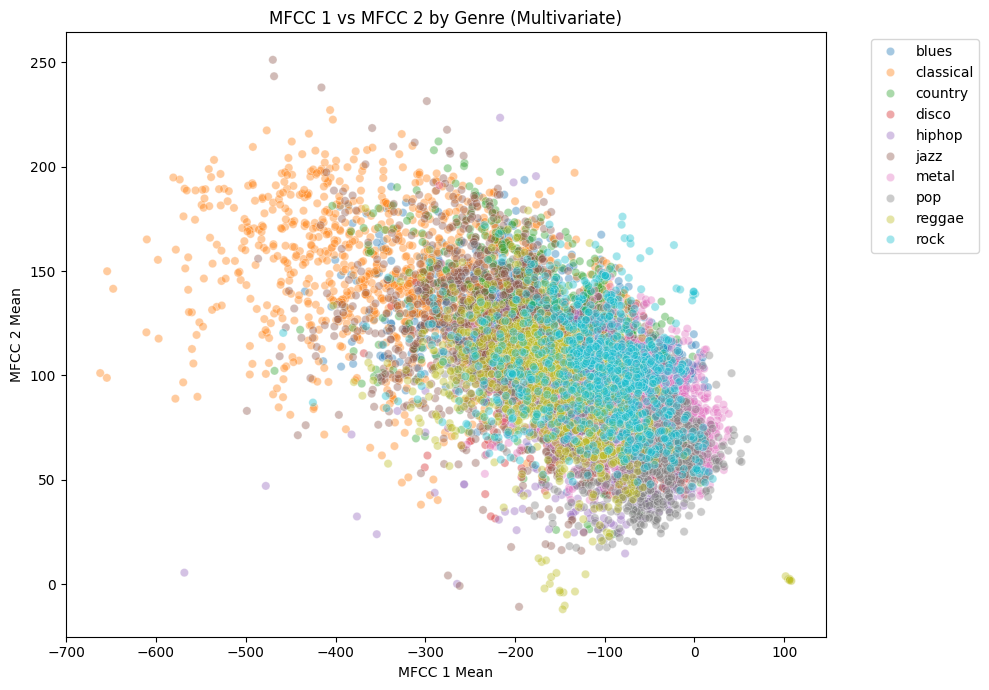

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='mfcc1_mean', y='mfcc2_mean', hue='label', alpha=0.4, palette='tab10')
plt.title('MFCC 1 vs MFCC 2 by Genre (Multivariate)')
plt.xlabel('MFCC 1 Mean')
plt.ylabel('MFCC 2 Mean')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The scatterplot of MFCC1 versus MFCC2 shows that some genres form loose clusters, but there is still substantial overlap among many classes. This indicates that the classification task is not trivial and that using only one or two MFCC features would not be enough for accurate prediction. However, the visible structure in the plot suggests that a combination of multiple audio features may still allow machine learning models to distinguish genres reasonably well.

In [ ]:
summary_table = df.groupby('label')[[
    'tempo',
    'spectral_centroid_mean',
    'spectral_bandwidth_mean',
    'rolloff_mean',
    'mfcc1_mean'
]].agg(['mean', 'std']).round(2)

summary_table

tempo        spectral_centroid_mean          \
             mean    std                   mean     std   
label                                                     
blues      126.69  35.26                1726.07  554.58   
classical  125.89  39.64                1351.32  412.93   
country    121.10  32.25                1891.19  611.40   
disco      122.73  19.16                2617.28  510.23   
hiphop     125.94  36.82                2521.52  542.22   
jazz       122.97  36.69                1790.28  723.02   
metal      124.99  27.80                2600.88  409.33   
pop        123.14  35.12                3069.99  646.81   
reggae     133.98  29.98                2182.21  674.52   
rock       121.43  29.80                2239.97  529.13   

          spectral_bandwidth_mean         rolloff_mean          mfcc1_mean  \
                             mean     std         mean      std       mean   
label                                                                        
blues                     1930.85  356.15      3632.91  1251.70    -166.17   
classical                 1519.53  311.55      2475.82   888.82    -324.32   
country                   2096.41  462.69      3938.47  1365.65    -145.95   
disco                     2512.36  368.04      5514.65  1089.77     -94.01   
hiphop                    2512.28  374.72      5327.69  1113.39    -103.55   
jazz                      2019.76  582.75      3744.72  1634.75    -215.44   
metal                     2242.82  225.44      5123.75   711.64     -63.46   
pop                       3006.80  353.37      6647.63  1347.03     -67.87   
reggae                    2309.80  407.65      4586.94  1284.21    -162.98   
rock                      2262.22  371.70      4664.78  1113.59    -110.66   

                   
              std  
label              
blues       89.33  
classical  118.66  
country     79.16  
disco       54.98  
hiphop      57.20  
jazz        85.73  
metal       52.80  
pop         61.01  
reggae      65.70  
rock        67.97

The summary table reports the mean and standard deviation of several selected audio features across genres. These results show that genres differ in meaningful ways across multiple feature types. For example, reggae has the highest average tempo, while pop has the highest average spectral centroid, spectral bandwidth, and rolloff, suggesting that it tends to contain brighter and higher-frequency audio content. In contrast, classical has noticeably lower average values for spectral centroid and bandwidth, indicating a different sound profile. The differences in MFCC1 mean across genres also suggest that timbre-related features may be useful for classification. Overall, this table supports the idea that the extracted audio features contain information that may help distinguish one genre from another.

Data Splitting and Cross-Validation

In order to evaluate model performance fairly, the dataset was divided into separate training and testing sets before fitting any machine learning models. The testing set was held out and only used at the end of the analysis to evaluate how well the final selected model generalized to new data. This is important because evaluating a model on the same data used to train it can give an overly optimistic picture of performance.
Because the outcome variable in this project is music genre, which has 10 classes, I used a stratified train-test split. Stratification keeps the proportion of each genre approximately the same in both the training and testing sets. Since the dataset is balanced across genres, preserving that balance during splitting helps ensure that each model is trained and evaluated under similar conditions for all classes.
After splitting the data, I used cross-validation on the training set to compare models and tune model settings. In particular, I used 5-fold stratified cross-validation, which works by dividing the training data into five smaller parts, or folds. In each round, four folds are used to train the model and one fold is used for validation. This process repeats five times so that each fold serves as the validation set once. The model’s cross-validation performance is then summarized by averaging the results across all five folds. Using cross-validation provides a more stable estimate of model performance than relying on a single validation split.
For this project, the predictors consist of the extracted audio features in features_3_sec.csv, while the response variable is the genre label. Variables such as the file name were not used as predictors, since they identify the audio segment rather than describe its musical content. Before fitting models that are sensitive to feature scale, numerical predictors were standardized so that variables measured on larger scales would not dominate variables measured on smaller scales.
Overall, this splitting and validation strategy helps reduce overfitting and makes the model comparison process more reliable. The training set is used for learning patterns and tuning models, cross-validation is used for selecting the best-performing approach, and the testing set is reserved for a final unbiased evaluation.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Define predictors and outcome
X = df.drop(columns=['label', 'filename'])
y = df['label']

# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining genre proportions:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting genre proportions:")
print(y_test.value_counts(normalize=True).sort_index())

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Training set shape: (7992, 58)
Testing set shape: (1998, 58)

Training genre proportions:
label
blues        0.100100
classical    0.099975
country      0.099850
disco        0.099975
hiphop       0.099850
jazz         0.100100
metal        0.100100
pop          0.100100
reggae       0.100100
rock         0.099850
Name: proportion, dtype: float64

Testing genre proportions:
label
blues        0.1001
classical    0.0996
country      0.0996
disco        0.1001
hiphop       0.1001
jazz         0.1001
metal        0.1001
pop          0.1001
reggae       0.1001
rock         0.1001
Name: proportion, dtype: float64


The dataset was split into 80% training data and 20% testing data using stratified sampling by genre. This produced 7,992 training observations and 1,998 testing observations. The genre proportions in both subsets remain very close to 10% for each class, confirming that the split preserved the balanced class distribution of the original dataset. I then used 5-fold stratified cross-validation on the training set to compare models and tune model settings before evaluating the final selected model on the held-out test set.

Limitation: rows are 3-second segments; segments from the same original song could still end up in both train and test.

Model Fitting

After preparing the data and defining the train-test split, the next step was to fit classification models that could predict the genre label from the extracted audio features. Because this is a multiclass classification problem with 10 possible genre categories, I selected models that are commonly used for tabular machine learning tasks and that can handle nonlinear relationships among predictors.
For this project, I fit three models: multinomial logistic regression, random forest, and support vector machine (SVM). Multinomial logistic regression serves as a useful baseline model because it is relatively simple and interpretable. Random forest is a tree-based ensemble method that can capture more complex relationships between features without requiring strong linearity assumptions. SVM is also well suited for classification problems and can perform well when the classes are not linearly separable.
Before fitting models that are sensitive to scale, such as logistic regression and SVM, the numerical predictors were standardized using the training data only. Standardization places all predictors on a comparable scale and helps prevent variables with larger numeric ranges from dominating the model. The random forest model does not require feature scaling, so it was fit directly on the original predictors.
To compare models fairly, each model was evaluated using the same 5-fold stratified cross-validation procedure defined in the previous section. Cross-validation accuracy was used as the main comparison metric during model fitting. In addition, hyperparameter tuning was performed to identify model settings that improved performance. For logistic regression, tuning focused on the regularization strength. For random forest, tuning focused on values such as the number of trees and maximum tree depth. For SVM, tuning focused on the penalty parameter and kernel-related settings.
The goal of this section is to determine which modeling approach performs best on the training data under cross-validation. The best-performing model from this process will then be evaluated on the held-out test set in the model performance section.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


Logistic Regression

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Logistic Regression pipeline
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        solver='lbfgs',
        max_iter=2000,
        random_state=42
    ))
])

log_reg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10]
}

log_reg_grid = GridSearchCV(
    estimator=log_reg_pipe,
    param_grid=log_reg_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression CV Accuracy:", log_reg_grid.best_score_)
print("Best Logistic Regression Parameters:", log_reg_grid.best_params_)

Best Logistic Regression CV Accuracy: 0.7217222747947128
Best Logistic Regression Parameters: {'model__C': 10}


As a baseline classification model, I fit a logistic regression model using the extracted audio features as predictors and genre as the response variable. Because logistic regression is sensitive to differences in feature scale, I standardized the predictors using StandardScaler within a pipeline. I then used grid search with 5-fold stratified cross-validation to tune the regularization parameter
C, testing the values 0.01, 0.1, 1, and 10.
The best-performing logistic regression model achieved a mean cross-validated accuracy of 0.722, or about 72.2%, on the training data. The best tuning parameter was C=10,indicating that weaker regularization produced the strongest performance among the values tested. This suggests that allowing the model to fit the feature patterns more flexibly improved its ability to distinguish between genres.
Overall, this is a strong baseline result for a 10-class classification problem. Since a random classifier would achieve only about 10% accuracy on a balanced dataset, the logistic regression model is capturing substantial information from the extracted audio features. However, because some genres overlap in the exploratory analysis, it is still possible that more flexible models may perform better.

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest pipeline
rf_pipe = Pipeline([
    ('model', RandomForestClassifier(random_state=42))
])

rf_param_grid = {
    'model__n_estimators': [100],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2],
    'model__min_samples_leaf': [1]
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest CV Accuracy:", rf_grid.best_score_)
print("Best Random Forest Parameters:", rf_grid.best_params_)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Best Random Forest CV Accuracy: 0.8529775728102905
Best Random Forest Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}


To compare a more flexible nonlinear model against logistic regression, I fit a Random Forest classifier using the extracted audio features as predictors and genre as the response variable. Random Forest is an ensemble learning method that builds many decision trees and combines their predictions. Unlike logistic regression, it can capture nonlinear patterns and interactions between predictors without requiring feature scaling.
I tuned the Random Forest model using grid search with 5-fold stratified cross-validation. The tuning parameters included the number of trees (n_estimators), the maximum tree depth (max_depth), the minimum number of observations required to split a node (min_samples_split), and the minimum number of observations required at a leaf (min_samples_leaf).
The best Random Forest model achieved a mean cross-validated accuracy of 0.853, or about 85.3%, on the training data. The best-performing parameter combination used 100 trees, no maximum depth limit, min_samples_split = 2, and min_samples_leaf = 1. This indicates that a relatively flexible tree-based model performed best among the values tested.
Compared with logistic regression, Random Forest performed substantially better. This suggests that the relationship between the extracted audio features and genre is not purely linear, and that a model capable of capturing more complex structure is better suited to this classification task.

SVM

In [ ]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(random_state=42))
])

svm_param_grid = {
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf'],
    'model__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM Parameters:", svm_grid.best_params_)
print("Best SVM CV Accuracy:", svm_grid.best_score_)

Best SVM Parameters: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVM CV Accuracy: 0.9100349796219633


To compare another flexible nonlinear classifier, I fit a Support Vector Machine (SVM) model using the extracted audio features as predictors and genre as the response variable. Because SVMs are sensitive to feature scale, I standardized the predictors using StandardScaler within a pipeline before fitting the model.
I tuned the SVM using grid search with 5-fold stratified cross-validation. The tuning parameters included the regularization parameter 
C, the kernel type, and the kernel coefficient gamma. I used a radial basis function (RBF) kernel, since it is well-suited for capturing nonlinear decision boundaries.
The best-performing SVM achieved a mean cross-validated accuracy of 0.910, or about 91.0%, on the training data. The best parameter combination used C=10, gamma = "scale", and an RBF kernel. This was the strongest result among all models considered. This suggests that the relationship between the extracted audio features and music genre is highly nonlinear. Compared to logistic regression and Random Forest, the SVM appears to capture the underlying structure of the data more effectively, making it the leading candidate for the final model.

Model Comparison

In [ ]:
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Best CV Accuracy': [
        log_reg_grid.best_score_,
        rf_grid.best_score_,
        svm_grid.best_score_
    ]
})

model_comparison['Best CV Accuracy'] = model_comparison['Best CV Accuracy'].round(3)
model_comparison = model_comparison.sort_values(by='Best CV Accuracy', ascending=False)
model_comparison

,Model,Best CV Accuracy
2,SVM,0.910
1,Random Forest,0.853
0,Logistic Regression,0.722


The model comparison results show that the Support Vector Machine performed best, with a mean cross-validated accuracy of 91.0%. Random Forest ranked second with 85.3%, while logistic regression had the lowest performance at 72.2%. These results suggest that genre classification based on extracted audio features benefits from flexible nonlinear models.

Model Performance

When applied to the test data, the final SVM achieved a test accuracy of 91.3%. This indicates that the model generalized well to new observations and that the strong cross-validation performance was not due to overfitting. In addition, the macro average F1-score and weighted average F1-score were both approximately 0.91, showing that performance was consistently high across genres.
The classification report shows that some genres were easier to classify than others. Metal had the strongest performance, with an F1-score of 0.97, while classical also performed very well with an F1-score of 0.95. These genres may be easier to identify because their audio characteristics are more distinct. In contrast, country and disco had somewhat lower F1-scores, suggesting that they are more likely to overlap with other genres in the extracted feature space.
The confusion matrix provides additional insight into these classification patterns. Most predictions fall along the diagonal, which indicates correct classification. However, there is a few noticeable confusions between genres with similar musical characteristics, such as overlap involving country, pop, disco, and rock. This suggests that while the model performs strongly overall, some genres share feature patterns that make them harder to separate perfectly.
Overall, the SVM provided the best balance of flexibility and predictive accuracy, which makes it the strongest model for this project.

SVM Test Accuracy: 0.9134134134134134

Classification Report:
              precision    recall  f1-score   support

       blues       0.90      0.94      0.92       200
   classical       0.92      0.98      0.95       199
     country       0.87      0.86      0.87       199
       disco       0.88      0.88      0.88       200
      hiphop       0.93      0.91      0.92       200
        jazz       0.92      0.94      0.93       200
       metal       0.98      0.95      0.97       200
         pop       0.94      0.86      0.90       200
      reggae       0.90      0.92      0.91       200
        rock       0.90      0.90      0.90       200

    accuracy                           0.91      1998
   macro avg       0.91      0.91      0.91      1998
weighted avg       0.91      0.91      0.91      1998



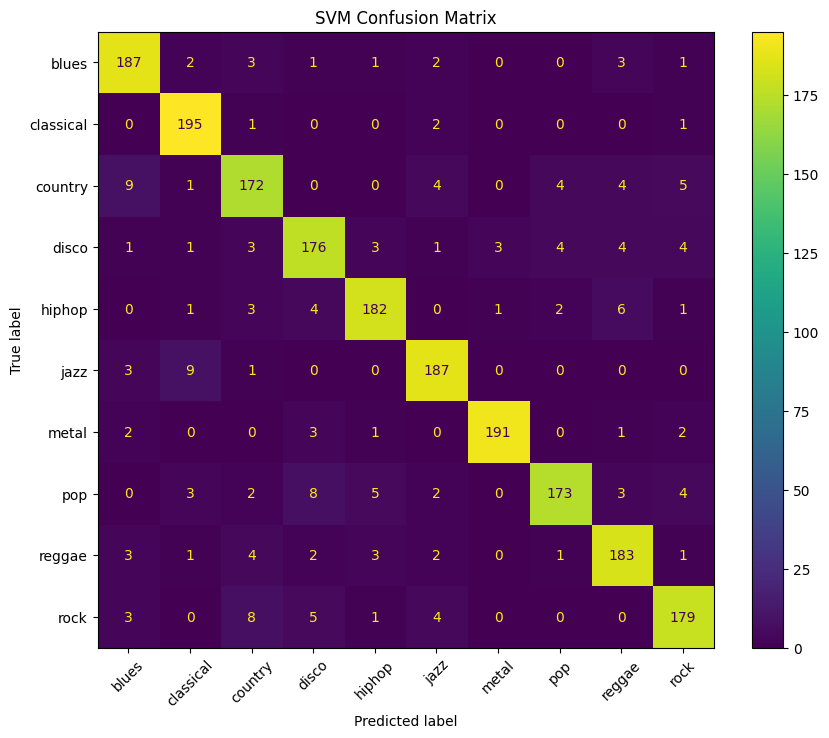

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Best SVM model
best_svm = svm_grid.best_estimator_

# Predict on test data
y_test_pred = best_svm.predict(X_test)

# Test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print("SVM Test Accuracy:", test_accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=best_svm.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_svm.classes_)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("SVM Confusion Matrix")
plt.show()

Conclusion

The goal of this project was to predict music genres using audio features from the GTZAN dataset. After exploring the data, splitting it into training and testing sets, and comparing different machine learning models, I found that the Support Vector Machine (SVM) performed the best. The SVM reached a cross-validation accuracy of 91.0% and a test accuracy of 91.3%, which was better than both logistic regression and random forest.
These results show that the extracted audio features are useful for telling music genres apart. Features like tempo, spectral measures, rolloff, and MFCCs helped the models make accurate predictions. The strong performance of the SVM also suggests that the differences between genres are complex, so a more flexible model worked better than a simpler one.
Even though the model performed very well overall, some genres were easier to predict than others. For example, metal and classical were classified more accurately, while country and disco were a little harder because they overlapped more with other genres. This matches the patterns seen earlier in the exploratory analysis.
One limitation of this project is that the data is based on 3-second clips instead of full songs. That can make genre prediction harder and may also cause clips from the same song to be very similar. In the future, this project could be improved by splitting the data by song, trying deep learning methods, or adding more audio features. Overall, this project shows that machine learning can work very well for classifying music genres when useful audio features are extracted from raw sound files.